# Imports

In [1]:
import time
#import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
#import imutils
import matplotlib.image as mpimg
from collections import OrderedDict
import pandas as pd

from skimage import io, transform
from math import *
import xml.etree.ElementTree as ET 
import pandas as pd
from skimage.transform import AffineTransform, warp
from skimage.transform import rotate as rotate_transform
from skimage.util import random_noise
from skimage.filters import gaussian
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from landmarks_datasets import LandmarksDataset
from landmarks_transforms import Transforms, UnNormalize
torch.cuda.empty_cache()

# Instantiate and check dataset
Plot a few samples with transforms enabled

In [6]:
DataSet = LandmarksDataset(Transforms())
# DataSet.NoTransF()

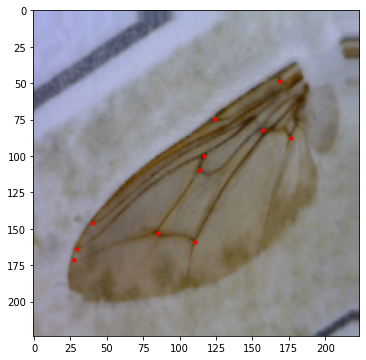

In [7]:
image_, landmarks = DataSet[0]
unorm = UnNormalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
image = unorm(image_)

landmarks = (landmarks + 0.5) * torch.tensor([224, 224])
image = image_.permute(1, 2, 0).numpy()

plt.figure(figsize=(10,6))
plt.imshow(image)
plt.scatter(landmarks[:,0], landmarks[:,1], s=10, color ='r')

In [8]:
class resnet50(nn.Module):
    def __init__(self,num_classes=22):
        super().__init__()
        self.model_name='resnet50'
        self.model=models.resnet50(pretrained=True)
        self.model.conv1=nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc=nn.Linear(self.model.fc.in_features, num_classes)
        
    def forward(self, x):
        x=self.model(x)
        return x

In [9]:
#DataSet.TransF()
#DataSet.resize(244)
dataset = DataSet
# split the dataset into validation and test sets
len_valid_test_set = int(0.2*len(dataset)) # 60% training, 20% validation, 20% testing

len_train_set = len(dataset) - len_valid_test_set*2

print("The length of Train set is {}".format(len_train_set))
print("The length of Valid set is {}".format(len_valid_test_set))
print("The length of Valid set is {}".format(len_valid_test_set))

train_dataset , valid_dataset, test_dataset  = torch.utils.data.random_split(dataset , [len_train_set, len_valid_test_set, len_valid_test_set], generator=torch.Generator().manual_seed(42))

# shuffle and batch the datasets
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=24, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=20, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=10, shuffle=True)



The length of Train set is 1452
The length of Valid set is 484
The length of Valid set is 484


In [10]:
# helper functions
import sys
import pickle

def print_overwrite(step, total_step, loss, operation):
    sys.stdout.write('\r')
    if operation == 'train':
        sys.stdout.write("Train Steps: %d/%d  Loss: %.8f " % (step, total_step, loss))   
    else:
        sys.stdout.write("Valid Steps: %d/%d  Loss: %.8f " % (step, total_step, loss))
        
    sys.stdout.flush()

In [11]:
import math
network = resnet50()
#network.load_state_dict(torch.load('C:/Projects/msc_haar/manuscript1_exp/regressors/models/model_resnet50_regressor_finetune_TransF_0.pth'))
network.cuda()

torch.autograd.set_detect_anomaly(True)


loss_list = {'train': [], 'val':[], 'time': []}   

criterion = nn.MSELoss()
optimizer = optim.Adam(network.parameters(), lr=0.001)

loss_min = np.inf
num_epochs = 100

start_time = time.time()
for epoch in range(1,num_epochs+1):
    loss_train = 0
    loss_valid = 0
    running_loss = 0
    
    network.train()
    for step in range(1,len(train_loader)+1):

        images, landmarks = next(iter(train_loader))
        
        images = images.cuda()
        landmarks = landmarks.view(landmarks.size(0),-1).cuda() 
      
        predictions = network(images)

        optimizer.zero_grad()
      
        
        # find the loss for the current step
    
        loss_train_step = criterion(predictions, landmarks)
  
        
        # calculate the gradients
 
        loss_train_step.backward()
    
        
        # update the parameters
  
        optimizer.step()
    
        loss_train += loss_train_step.item()
        running_loss = loss_train/step
        
        print_overwrite(step, len(train_loader), running_loss, 'train')
        
    network.eval() 
    with torch.no_grad():
        
        for step in range(1,len(valid_loader)+1):
            
  
            images, landmarks = next(iter(valid_loader))
   
            images = images.cuda()
            landmarks = landmarks.view(landmarks.size(0),-1).cuda()
        
            predictions = network(images)

            # find the loss for the current step
            loss_valid_step = criterion(predictions, landmarks)

            loss_valid += loss_valid_step.item()
            running_loss = loss_valid/step

            print_overwrite(step, len(valid_loader), running_loss, 'valid')
    
    loss_train /= len(train_loader)
    loss_valid /= len(valid_loader)
    
    print('\n--------------------------------------------------')
    print('Epoch: {}  Train Loss: {:.8f}  Valid Loss: {:.8f}'.format(epoch, loss_train, loss_valid))
    print('--------------------------------------------------')
    loss_list['train'].append(loss_train)
    loss_list['val'].append(loss_valid)
    #loss_list['time'].append(time.time()-start_time)
    f = open("saved-models/model_resnet50_regressor_finetune_TransF_trainingdata_0.pkl","wb")
    pickle.dump(loss_list,f)
    f.close()
    if loss_valid < loss_min:
        loss_min = loss_valid
        torch.save(network.state_dict(), 'saved-models/model_resnet50_regressor_finetune_TransF_0.pth') 
        print("\nMinimum Validation Loss of {:.8f} at epoch {}/{}".format(loss_min, epoch, num_epochs))
        print('Model Saved\n')
     #0.000034
    
print('Training Complete')
print("Total Elapsed Time : {} s".format(time.time()-start_time))
loss_list['time'].append(time.time()-start_time)

Valid Steps: 25/25  Loss: 0.00237305 
--------------------------------------------------
Epoch: 1  Train Loss: 0.01742231  Valid Loss: 0.00237305
--------------------------------------------------

Minimum Validation Loss of 0.00237305 at epoch 1/100
Model Saved

Train Steps: 54/61  Loss: 0.00165161 

AxisError: axis 1 is out of bounds for array of dimension 0